# Project 3 · 02：第一个 Toy NPU——真实 BYOC 与故障实验室

> **一句话心智模型：你亲手给一段计算图分配后端，生成一份可执行合同，再让 TVM VM 真正调用你注册的 runtime；每个故障都停在一个可观察的阶段。**

先看实际计算：`x[2,32] @ w[32,16] + bias[16] → ReLU`。TinyNPU 只接走 MatMul+Add，ReLU 留在 host。这里 M=2 是样本/行轴，K=32 是乘加消去的 reduction 轴，N=16 是输出列轴；没有独立 batch 轴。

这本承接 `01_relax_pattern_partition_backend_contract.ipynb`，对应 `Learning-Guide.md` §14–15。先把下面链路做穿，再做 kernel、layout、异步 runtime 的下一本。

```text
Relax graph → pattern → support → partition → RunCodegen
                                                ↓
                                   JSON 指令 + LLVM 调用桥
                                                ↓
TVM VM → call_dps_packed → 注册的 TinyNPU runtime → NumPy CPU
  ↓
host ReLU / sin → 逐层与最终结果校验
```

**实验边界**：真实使用 TVM 0.26 的 pattern registry、分区 pass、external codegen、runtime registry 和 VM；TinyNPU 指令由 Python/NumPy 同步解释执行。LLVM 只编译调用桥和 host 部分，没生成优化的 NPU kernel；没有调用 M1 GPU/ANE，没有模拟 DMA/stream/片上 SRAM，没有硬件性能结论。JSON 是本教学后端自定格式，不冒充厂商格式。

完成内容：三个 fused patterns；FP16/static/alignment 合同；dtype、K、N、dynamic、交换操作数、插入 cast/reshape、分支泄漏故障；codegen、runtime lookup、workspace、错误输出故障；修复回归与证据保存。

## 1 · Setup：用当前仓库的 uv 环境

在仓库根目录执行 `uv sync --locked`（严格按锁文件安装），然后 `uv run jupyter lab`（使用这个虚拟环境启动编辑器）。选该环境的 Python kernel，Run All。

无界面验证：
```bash
uv run jupyter nbconvert --execute --to notebook --inplace notebooks/project3_backend_autotuning/02_toy_npu_codegen_runtime_fault_lab.ipynb
```
`--execute` 从头运行，`--to notebook` 保留 notebook 格式，`--inplace` 保存输出。默认单 cell 超时可通过 `--ExecutePreprocessor.timeout=300` 调整。

本机 Xcode 许可未接受时，torch 可选 DLPack JIT 扩展会警告；这里使用 TVM 自带 LLVM 的内存 JIT 和普通 tensor copy 路径，不依赖那个扩展。**环境错误不能当作预期故障 case 的成功。**

In [1]:
import os
os.environ['TVM_NUM_THREADS'] = '1'
import json, hashlib, platform, sys
from pathlib import Path
from datetime import datetime, timezone
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
import tvm, tvm_ffi
from tvm import relax, te, tirx
from tvm.relax.dpl import wildcard, is_op
from tvm.relax.backend.pattern_registry import register_patterns, get_patterns_with_prefix
from tvm.relax.backend.utils import has_leaking_intermediate_variables

assert tvm.__version__ == '0.26.0', '本教程锁定 TVM 0.26.0，请使用仓库 uv 环境'
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p/'Learning-Guide.md').exists())
RUN = ROOT/'artifacts'/'toy_npu'/datetime.now(timezone.utc).strftime('%Y%m%dT%H%M%S%fZ')
RUN.mkdir(parents=True)
BACKEND = 'toy_npu_v1'
TARGET = 'llvm'
SEED = 17
plt.rcParams.update({'figure.figsize': (9, 4), 'font.size': 10})
print({'python':sys.version.split()[0], 'tvm':tvm.__version__,
       'machine':platform.machine(), 'execution':'CPU synchronous', 'artifacts':str(RUN)})

/Users/yhwang/infer-proj/.venv/lib/python3.12/site-packages/tvm_ffi/_optional_torch_c_dlpack.py:192: UserWarning: Failed to JIT torch c dlpack extension, EnvTensorAllocator will not be enabled.
We recommend installing via `pip install torch-c-dlpack-ext`
  warnings.warn(


{'python': '3.12.11', 'tvm': '0.26.0', 'machine': 'arm64', 'execution': 'CPU synchronous', 'artifacts': '/Users/yhwang/infer-proj/artifacts/toy_npu/20260919T020521064207Z'}


/Users/yhwang/infer-proj/.venv/lib/python3.12/site-packages/tvm_ffi/_optional_torch_c_dlpack.py:192: UserWarning: Failed to JIT torch c dlpack extension, EnvTensorAllocator will not be enabled.
We recommend installing via `pip install torch-c-dlpack-ext`
  warnings.warn(


## 2 · 先把乘加算出来，再造 IR

先用一个不满足硬件对齐限制的 2×2 小例子理解数值，再放大到合法的 K=32、N=16：

| 输出 | 乘加 | 加 bias | ReLU |
|---|---|---|---|
| y[0,0] | 1×1 + 2×3 = 7 | 7−10 = −3 | 0 |
| y[0,1] | 1×2 + 2×4 = 10 | 10+1 = 11 | 11 |
| y[1,0] | 3×1 + 4×3 = 15 | 15−10 = 5 | 5 |
| y[1,1] | 3×2 + 4×4 = 22 | 22+1 = 23 | 23 |

**Relax** 是 TVM 保存 tensor 级程序的 IR，代码里由 Function、Var、Call、Binding 维护依赖；**TIR** 是保存循环、buffer 与索引的低层 IR，本版本 Python 名为 `tirx`。`BlockBuilder.emit` 生成一个 SSA binding，而不是立即计算 NumPy 数组。

下面工厂直接构造 Relax，避免第一本同时引入 ONNX 导入与 exporter 版本问题。`gap` 故意插一层结构；`leak` 让 MatMul 中间值被另一个输出使用。

In [2]:
def make_graph(kind='matmul_add', M=2, K=32, N=16, dtype='float16',
               dynamic=False, swapped=False, gap=None, leak=False):
    bb = relax.BlockBuilder()
    k = tirx.Var('K', 'int64') if dynamic else K
    shapes = {'matmul_add': [(M,k),(k,N),(N,)],
              'conv_relu': [(1,16,3,3),(16,16,1,1)],
              'add_layernorm': [(M,N),(M,N),(N,),(N,)]}[kind]
    params = [relax.Var(f'p{i}', relax.TensorType(s,dtype)) for i,s in enumerate(shapes)]
    with bb.function('main', params):
        with bb.dataflow():
            if kind == 'matmul_add':
                middle = bb.emit(relax.op.matmul(params[0],params[1]), 'matmul')
                z = middle
                if gap == 'reshape': z = bb.emit(relax.op.reshape(z,(M,N)))
                if gap == 'cast': z = bb.emit(relax.op.astype(z,dtype))
                pair = (params[2],z) if swapped else (z,params[2])
                z = bb.emit(relax.op.add(*pair), 'bias_add')
                z = bb.emit(relax.op.nn.relu(z), 'host_relu')
                if leak: z = relax.Tuple([z, middle])
            elif kind == 'conv_relu':
                z = bb.emit(relax.op.nn.conv2d(params[0],params[1],
                            data_layout='NCHW',kernel_layout='OIHW'), 'conv')
                z = bb.emit(relax.op.nn.relu(z), 'relu')
                z = bb.emit(relax.op.sin(z), 'host_sin')
            else:
                z = bb.emit(relax.op.add(params[0],params[1]), 'residual_add')
                z = bb.emit(relax.op.nn.layer_norm(z,params[2],params[3],
                            axes=[-1],epsilon=1e-5), 'layernorm')
                z = bb.emit(relax.op.sin(z), 'host_sin')
            out = bb.emit_output(z)
        bb.emit_func_output(out)
    return bb.get()

original = make_graph()
print(original.script())

# from tvm.script import ir as I
# from tvm.script import relax as R

@I.ir_module
class Module:
    @R.function
    def main(p0: R.Tensor((2, 32), dtype="float16"), p1: R.Tensor((32, 16), dtype="float16"), p2: R.Tensor((16,), dtype="float16")) -> R.Tensor((2, 16), dtype="float16"):
        with R.dataflow():
            matmul: R.Tensor((2, 16), dtype="float16") = R.matmul(p0, p1, out_dtype=None)
            bias_add: R.Tensor((2, 16), dtype="float16") = R.add(matmul, p2)
            host_relu: R.Tensor((2, 16), dtype="float16") = R.nn.relu(bias_add)
            gv: R.Tensor((2, 16), dtype="float16") = host_relu
            R.output(gv)
        return gv


## 3 · 给 backend 写可拒绝的合同

**pattern matching** 就是沿 graph 的依赖边找指定的 Call 结构；它类似编译器 instruction selection 的形状匹配。**support predicate** 再决定当前形状和类型能不能由这个实现接走。两个阶段不可合并成“op 在支持列表”。

| Pattern | 本 Toy 的实现合同（自定，不是 ANE 规格） |
|---|---|
| MatMul+Add | rank-2，FP16，所有维度静态且正数；K%32=0，N%16=0；bias=[N] |
| Conv+ReLU | FP16，NCHW/OIHW，1×1，stride=1、padding=0、dilation=1、groups=1；输入/输出通道%16=0 |
| Add+LayerNorm | FP16，两输入同形 rank-2，最后一轴归一化，gamma/beta=[N]，N%16=0 |

原需求中的 C%16 限制用于 Conv 通道；MatMul 列轴叫 N，不能把 C、K、N 混作同一维。Conv 的 N 是 batch，而本教程 MatMul 的 N 是输出列。这里特意用不同语义说明同名字母陷阱。

`has_leaking_intermediate_variables` 查 def-use：中间结果被 region 外使用时，拒绝这个只导出一个结果的实现。拒绝不等于任何后端都不可能实现多输出。

In [3]:
support_log = []

def tensor_meta(expr):
    info = expr.ty
    shape = info.shape
    dims = list(shape.values) if isinstance(shape,relax.ShapeExpr) else []
    return str(info.dtype), [int(d) if isinstance(d,tirx.IntImm) else None for d in dims]

def contract(ctx, kind):
    a = ctx.annotated_expr
    names = {'matmul_add':['x','w','b'], 'conv_relu':['x','w'],
             'add_layernorm':['x','b','g','beta']}[kind]
    meta = {name:tensor_meta(a[name]) for name in names}
    reason = 'accepted'
    if has_leaking_intermediate_variables(ctx): reason = 'boundary: intermediate escapes'
    elif any(dtype != 'float16' for dtype,shape in meta.values()): reason = 'dtype: FP16 only'
    elif any(not shape or any(d is None for d in shape) for _,shape in meta.values()):
        reason = 'shape: static only'
    elif any(d <= 0 for _,shape in meta.values() for d in shape): reason = 'shape: positive only'
    else:
        s = {name:shape for name,(_,shape) in meta.items()}
        if kind == 'matmul_add':
            if len(s['x'])!=2 or len(s['w'])!=2: reason='rank: 2D only'
            elif s['x'][1] != s['w'][0] or s['b'] != [s['w'][1]]: reason='shape: operand mismatch'
            elif s['x'][1]%32: reason='alignment: K % 32'
            elif s['w'][1]%16: reason='alignment: N % 16'
        elif kind == 'conv_relu':
            attr=a['core'].attrs
            if (str(attr.data_layout)!='NCHW' or str(attr.kernel_layout)!='OIHW'
                or str(attr.out_layout) not in ('','NCHW') or int(attr.groups)!=1
                or list(attr.strides)!=[1,1] or list(attr.padding)!=[0,0,0,0]
                or list(attr.dilation)!=[1,1] or s['w'][2:]!=[1,1]):
                reason='conv: only NCHW 1x1 unit-stride'
            elif s['x'][1] != s['w'][1] or s['x'][1]%16 or s['w'][0]%16:
                reason='alignment: channels % 16'
        else:
            if (len(s['x'])!=2 or s['x']!=s['b'] or s['g']!=[s['x'][-1]]
                or s['beta']!=s['g']): reason='layernorm: shape'
            elif list(a['out'].attrs.axes) not in ([-1],[1]): reason='layernorm: last axis only'
            elif s['x'][-1]%16: reason='alignment: N % 16'
    support_log.append({'pattern':kind, 'reason':reason})
    return reason == 'accepted'

def install_patterns(commutative=False):
    x,w,b,g,beta = [wildcard() for _ in range(5)]
    mm=is_op('relax.matmul')(x,w)
    add=is_op('relax.add')(mm,b)
    if commutative: add=add | is_op('relax.add')(b,mm)
    conv=is_op('relax.nn.conv2d')(x,w)
    relu=is_op('relax.nn.relu')(conv)
    residual=is_op('relax.add')(x,b)
    ln=is_op('relax.nn.layer_norm')(residual,g,beta)
    definitions=[('matmul_add',add,{'x':x,'w':w,'b':b,'core':mm,'out':add}),
                 ('conv_relu',relu,{'x':x,'w':w,'core':conv,'out':relu}),
                 ('add_layernorm',ln,{'x':x,'b':b,'g':g,'beta':beta,'core':residual,'out':ln})]
    register_patterns([(BACKEND+'.'+kind,p,ann,lambda ctx,k=kind:contract(ctx,k))
                       for kind,p,ann in definitions])

install_patterns()
def partition(mod):
    support_log.clear()
    return relax.transform.FuseOpsByPattern(
        get_patterns_with_prefix(BACKEND+'.'), annotate_codegen=True)(mod)

def regions(mod):
    return [f for f in mod.functions.values()
            if isinstance(f,relax.Function) and f.attrs and 'Codegen' in f.attrs]

part = partition(original)
assert len(regions(part)) == 1
print(part.script())
display(pd.DataFrame(support_log))

# from tvm.script import ir as I
# from tvm.script import relax as R

@I.ir_module
class Module:
    @R.function
    def fused_relax_matmul_relax_add_toy_npu_v1(p0: R.Tensor((2, 32), dtype="float16"), p1: R.Tensor((32, 16), dtype="float16"), p2: R.Tensor((16,), dtype="float16")) -> R.Tensor((2, 16), dtype="float16"):
        R.func_attr({"Codegen": "toy_npu_v1"})
        # from tvm.script import relax as R
        
        @R.function
        def local_func(p0_1: R.Tensor((2, 32), dtype="float16"), p1_1: R.Tensor((32, 16), dtype="float16"), p2_1: R.Tensor((16,), dtype="float16")) -> R.Tensor((2, 16), dtype="float16"):
            R.func_attr({"Composite": "toy_npu_v1.matmul_add"})
            with R.dataflow():
                matmul: R.Tensor((2, 16), dtype="float16") = R.matmul(p0_1, p1_1, out_dtype=None)
                gv: R.Tensor((2, 16), dtype="float16") = R.add(matmul, p2_1)
                R.output(gv)
            return gv

        output: R.Tensor((2, 16), dtype="float16") =

,pattern,reason
0,matmul_add,accepted


## 4 · External codegen：读真实 region，生成 JSON 指令和 LLVM 调用桥

**codegen（code generation）** 在这里把 region 内部 Call 生成 JSON 指令，把外层函数参数映射为编号；再生成一个 LLVM runtime module，里面的同名函数调用 `toy_npu_v1.execute`。**compiler lowering** 是把高层表达变成更具体实现；这里从 Relax 到 JSON/调用桥就是一次这样的细化。

三个容器就够：`env` 是 Var→指令编号的符号表，`nodes` 是按依赖顺序排列的指令列表，`inputs` 是外层 ABI 的参数编号。**不能假设交换 Add 后参数顺序仍是 x,w,b**；读取 region 本身才能保证语义正确。

`te.extern` 声明“输出由外部函数写入”，`call_packed` 调用注册函数。DPS = destination-passing style：VM 分配 output，再把它作为最后一个参数传入，runtime 必须写它。这段桥可在下方直接 dump TIR 检视。

In [4]:
def encode_region(func):
    nodes=[]
    def visit(expr, env):
        if isinstance(expr,relax.Var): return env[expr]
        if isinstance(expr,relax.Function): return expr
        if isinstance(expr,relax.SeqExpr):
            local=dict(env)
            for block in expr.blocks:
                for binding in block.bindings:
                    local[binding.var]=visit(binding.value,local)
            return visit(expr.body,local)
        if isinstance(expr,relax.Call):
            if isinstance(expr.op,relax.Var):
                inner=env[expr.op]
                args=[visit(arg,env) for arg in expr.args]
                return visit(inner.body,dict(zip(inner.params,args)))
            op=expr.op.name
            args=[visit(arg,env) for arg in expr.args]
            attrs={}
            if op=='relax.nn.layer_norm':
                attrs={'epsilon':float(expr.attrs.epsilon),'axes':[int(v) for v in expr.attrs.axes]}
            dtype,shape=tensor_meta(expr)
            index=len(nodes)
            nodes.append({'op':op,'inputs':args,'dtype':dtype,'shape':shape,'attrs':attrs})
            return index
        raise TypeError(f'Unexpected IR node: {type(expr)}')
    env={}
    for i,param in enumerate(func.params):
        dtype,shape=tensor_meta(param)
        env[param]=len(nodes)
        nodes.append({'op':'input','arg':i,'dtype':dtype,'shape':shape})
    output=visit(func.body,env)
    return {'schema':1,'symbol':str(func.attrs['global_symbol']), 'nodes':nodes,'output':output}

codegen_log=[]
bridge_ir=[]
codegen_fault=False

@tvm.register_global_func('relax.ext.'+BACKEND, override=True)
def toy_codegen(funcs, options, constant_names):
    if codegen_fault: raise RuntimeError('TOY_CODEGEN_REJECT')
    modules=[]
    for func in funcs:
        spec=encode_region(func)
        payload=json.dumps(spec,sort_keys=True)
        args=[te.placeholder(tensor_meta(p)[1],tensor_meta(p)[0],name=f'arg{i}')
              for i,p in enumerate(func.params)]
        out_info=spec['nodes'][spec['output']]
        out=te.extern(out_info['shape'],args,
                      lambda ins,outs:tirx.call_packed(BACKEND+'.execute',payload,*ins,*outs),
                      dtype=out_info['dtype'],name='external_dispatch')
        prim=te.create_prim_func([*args,out]).with_attr('global_symbol',spec['symbol'])
        modules.append(tirx.build(prim,target=TARGET))
        codegen_log.append(spec)
        bridge_ir.append(prim.script())
    return modules

## 5 · Runtime：装载指令，选择实现，写回结果

**runtime** 是运行时负责函数查找、执行与结果回写的代码；此处没有 OS 调度器或硬件 scheduler。`kernels` 是 op-name→callable 字典，类似函数表；查不到时报明确错误，**不自动吞掉异常转 CPU fallback**（本来就全在 CPU）。

FP16 是输入/输出合同；NumPy runtime 的乘加与 LayerNorm 统计使用 FP32，再在每个原始 op 边界舍入为 FP16。这样既清楚精度策略，也保留逐层 parity 的观测点。Graph fusion 在这里代表统一 region 调用，并未合并 NumPy 的临时数组或物理 kernel。

Conv 输入 `[batch,channel,height,width]`，权重 `[out_channel,in_channel,1,1]`；1×1 Conv 的每个像素就是对 input channel 做 reduction。LayerNorm 输入 `[row,feature]`，每行沿 feature 求均值/方差，然后乘 gamma 加 beta。

In [5]:
def layernorm(a,attrs):
    x,gamma,beta=a
    axes=tuple(attrs['axes'])
    mean=x.mean(axis=axes,keepdims=True)
    var=((x-mean)**2).mean(axis=axes,keepdims=True)
    return (x-mean)/np.sqrt(var+attrs['epsilon'])*gamma+beta

kernels={
 'relax.matmul':lambda a,attrs:a[0]@a[1],
 'relax.add':lambda a,attrs:a[0]+a[1],
 'relax.nn.relu':lambda a,attrs:np.maximum(a[0],0),
 'relax.nn.conv2d':lambda a,attrs:np.einsum('nchw,oc->nohw',a[0],a[1][:,:,0,0]),
 'relax.nn.layer_norm':layernorm,
}
runtime_log=[]
runtime_fault=None
workspace_budget=1_000_000

@tvm.register_global_func(BACKEND+'.execute',override=True)
def toy_execute(payload,*buffers):
    spec=json.loads(payload)
    event={'symbol':spec['symbol'],'executor':'NumPy CPU','status':'entered','layers':[]}
    runtime_log.append(event)
    # 一个可复现的资源准入模型：所有中间节点输出之和；不是实际峰值内存。
    required=sum(int(np.prod(n['shape']))*np.dtype(n['dtype']).itemsize
                 for n in spec['nodes'] if n['op']!='input')
    if required>workspace_budget:
        event['status']='workspace_error'
        raise RuntimeError('TOY_WORKSPACE_EXHAUSTED')
    values=[]
    for node in spec['nodes']:
        if node['op']=='input': value=buffers[node['arg']].numpy()
        else:
            if runtime_fault=='missing_kernel' and node['op']=='relax.matmul':
                event['status']='lookup_error'
                raise RuntimeError('TOY_KERNEL_UNAVAILABLE')
            args=[values[i].astype('float32') for i in node['inputs']]
            value=kernels[node['op']](args,node['attrs']).astype(node['dtype'])
            event['layers'].append({'op':node['op'],'value':value.copy()})
        values.append(value)
    result=values[spec['output']]
    if runtime_fault=='corrupt_output': result=result+np.array(1,dtype=result.dtype)
    buffers[-1].copyfrom(result)
    event['status']='completed'

def compile_vm(mod):
    planned=partition(mod)
    lowered=relax.transform.RunCodegen()(planned)
    exe=relax.build(lowered,target=TARGET)
    return planned,lowered,relax.VirtualMachine(exe,tvm.cpu())

part,lowered,vm=compile_vm(original)
assert len(lowered.attrs['external_mods'])==1
assert 'call_dps_packed' in lowered.script()
print(lowered.script())
print(bridge_ir[-1])
display(codegen_log[-1])

# from tvm.script import ir as I
# from tvm.script import relax as R

@I.ir_module
class Module:
    I.module_attrs({"external_mods": [metadata["ffi.Module"][0]]})
    @R.function
    def main(p0: R.Tensor((2, 32), dtype="float16"), p1: R.Tensor((32, 16), dtype="float16"), p2: R.Tensor((16,), dtype="float16")) -> R.Tensor((2, 16), dtype="float16"):
        with R.dataflow():
            lv = R.call_dps_packed("fused_relax_matmul_relax_add_toy_npu_v1", (p0, p1, p2), out_ty=R.Tensor((2, 16), dtype="float16"))
            host_relu: R.Tensor((2, 16), dtype="float16") = R.nn.relu(lv)
            gv: R.Tensor((2, 16), dtype="float16") = host_relu
            R.output(gv)
        return gv

# Metadata omitted. Use show_meta=True in script() method to show it.
# from tvm.script import tirx as T
# from tvm.tirx.layout import Axis

@T.prim_func(s_tir=True)
def fused_relax_matmul_relax_add_toy_npu_v1(arg0: T.Buffer((2, 32), "float16", offset_factor=1), arg1: T.Buffer((32, 16), "float16", offset_

{'schema': 1,
 'symbol': 'fused_relax_matmul_relax_add_toy_npu_v1',
 'nodes': [{'op': 'input', 'arg': 0, 'dtype': 'float16', 'shape': [2, 32]},
  {'op': 'input', 'arg': 1, 'dtype': 'float16', 'shape': [32, 16]},
  {'op': 'input', 'arg': 2, 'dtype': 'float16', 'shape': [16]},
  {'op': 'relax.matmul',
   'inputs': [0, 1],
   'dtype': 'float16',
   'shape': [2, 16],
   'attrs': {}},
  {'op': 'relax.add',
   'inputs': [3, 2],
   'dtype': 'float16',
   'shape': [2, 16],
   'attrs': {}}],
 'output': 4}

## 6 · 三个正常路径：逐层对照 + 最终输出 + runtime event

参考路径用 PyTorch FP32 运算，并在相同 op 边界显式舍入到 FP16；与 NumPy backend 分开实现。额外比较完整 FP32 reference，展示 FP16 舍入误差。容差不是“误差越小越好”的空话：本例小输入采用 `atol=0.005, rtol=0.03`，仅用于这些受控数据，不能直接当模型任务精度门禁。

MatMul 案例每次只调用一次 TinyNPU region，最后 ReLU 留在 host；另外两图把 sin 留在 host。保存 layer 数组才能证明不是“只看最终值恰好对”。

In [6]:
import torch

def make_inputs(kind='matmul_add',M=2,K=32,N=16,dtype='float16'):
    rng=np.random.default_rng(SEED)
    shapes={'matmul_add':[(M,K),(K,N),(N,)],
            'conv_relu':[(1,16,3,3),(16,16,1,1)],
            'add_layernorm':[(M,N),(M,N),(N,),(N,)]}[kind]
    return [(rng.standard_normal(s)*0.2).astype(dtype) for s in shapes]

def reference(arrays,kind='matmul_add',round_ops=True):
    a=[torch.from_numpy(v.astype('float32')) for v in arrays]
    dtype=arrays[0].dtype
    def boundary(t):
        return t.to(torch.float16).float() if round_ops and dtype==np.float16 else t
    if kind=='matmul_add':
        z=boundary(a[0]@a[1]); y=boundary(z+a[2]); layers=[z,y]
        final=torch.relu(y)
    elif kind=='conv_relu':
        z=boundary(torch.nn.functional.conv2d(a[0],a[1])); y=boundary(torch.relu(z)); layers=[z,y]
        final=boundary(torch.sin(y))
    else:
        z=boundary(a[0]+a[1]); y=boundary(torch.nn.functional.layer_norm(z,(z.shape[-1],),a[2],a[3],1e-5))
        layers=[z,y]; final=boundary(torch.sin(y))
    return final.numpy().astype(dtype),[v.numpy().astype(dtype) for v in layers]

def invoke(vm,arrays):
    return vm['main'](*[tvm.runtime.tensor(v) for v in arrays])

def parity(got,expected):
    assert got.shape==expected.shape and np.isfinite(got).all()
    np.testing.assert_allclose(got,expected,atol=0.005,rtol=0.03)

normal_rows=[]
normal_vms={}
for kind in ['matmul_add','conv_relu','add_layernorm']:
    mod=make_graph(kind)
    p,l,v=compile_vm(mod)
    normal_vms[kind]=v
    arrays=make_inputs(kind)
    runtime_log.clear()
    got=invoke(v,arrays).numpy()
    expected,layers=reference(arrays,kind)
    fp32,_=reference([a.astype('float32') for a in arrays],kind,False)
    parity(got,expected)
    assert len(runtime_log)==1 and runtime_log[0]['status']=='completed'
    observed=runtime_log[0]['layers']
    assert len(observed)==len(layers)
    for record,golden in zip(observed,layers): parity(record['value'],golden)
    normal_rows.append({'pattern':kind,'regions':len(regions(p)), 'runtime_calls':len(runtime_log),
                        'layer_parity':True,'max_abs_error':float(np.max(np.abs(got.astype('float32')-expected))),
                        'vs_FP32_max_abs':float(np.max(np.abs(got.astype('float32')-fp32)))})
    (RUN/f'{kind}_before.py').write_text(mod.script())
    (RUN/f'{kind}_partition.py').write_text(p.script())
    (RUN/f'{kind}_codegen.py').write_text(l.script())
    np.savez(RUN/f'{kind}_parity.npz',output=got,reference=expected,fp32=fp32,
             **{f'input_{i}':a for i,a in enumerate(arrays)},
             **{f'layer_{i}':r['value'] for i,r in enumerate(observed)},
             **{f'golden_{i}':a for i,a in enumerate(layers)})
normal_table=pd.DataFrame(normal_rows)
display(normal_table)

,pattern,regions,runtime_calls,layer_parity,max_abs_error,vs_FP32_max_abs
0,matmul_add,1,1,True,0.0,0.000278
1,conv_relu,1,1,True,0.0,0.000171
2,add_layernorm,1,1,True,0.0,0.000307


## 7 · Compile-time 故障矩阵：一次只改一个因素

先预测每行在哪一级失败，然后运行。`structural` 使用 **同一 pattern、永远返回 True 的 checker** 计数，和实际 support checker 分开：因此不是靠“日志为空”猜 pattern 是否匹配。

动态 K 只是在编译时无法证明能满足合同；本版本选择保守拒绝。在 runtime 传入 K=32 后 host 仍能执行，不代表 backend 具备 runtime guard。K=1024 与 K=1000 这组原始要求也实际执行。

交换 Add 的行为要实测：不要预设 TVM 会自动做交换律匹配。相同 dtype Cast 和相同 shape Reshape 本身不改数值，但会改变当前 pass 所见结构；若未来上游消除了它们，结果可以不同。

In [7]:
cases={
 'baseline':{}, 'fp32':{'dtype':'float32'},
 'K1024':{'K':1024}, 'K1000':{'K':1000}, 'N15':{'N':15},
 'dynamic_K':{'dynamic':True}, 'swapped_add':{'swapped':True},
 'reshape_gap':{'gap':'reshape'}, 'cast_gap':{'gap':'cast'},
 'escaping_matmul':{'leak':True},
}
expected_regions={'baseline':1,'fp32':0,'K1024':1,'K1000':0,'N15':0,
                  'dynamic_K':0,'swapped_add':1,'reshape_gap':0,'cast_gap':0,'escaping_matmul':0}

def structural_count(mod):
    patterns=[relax.transform.FusionPattern(p.name,p.pattern,p.annotation_patterns,lambda ctx:True)
              for p in get_patterns_with_prefix(BACKEND+'.')]
    structural=relax.transform.FuseOpsByPattern(patterns,annotate_codegen=True)(mod)
    return len(regions(structural))

case_rows=[]
for name,opts in cases.items():
    mod=make_graph(**opts)
    count=structural_count(mod)
    p=partition(mod)
    reasons=sorted(set(r['reason'] for r in support_log))
    n=len(regions(p))
    assert n==expected_regions[name], (name,n,reasons)
    lowered_case=relax.transform.RunCodegen()(p)
    case_vm=relax.VirtualMachine(relax.build(lowered_case,target=TARGET),tvm.cpu())
    input_opts={k:v for k,v in opts.items() if k in ('M','K','N','dtype')}
    arrays=make_inputs(**input_opts)
    runtime_log.clear()
    output=invoke(case_vm,arrays)
    expected,layers=reference(arrays)
    if opts.get('leak'):
        parity(output[0].numpy(),expected); parity(output[1].numpy(),layers[0])
    else: parity(output.numpy(),expected)
    assert len(runtime_log)==n
    row={'case':name,'structural_regions':count,'accepted_regions':n,
         'reason':'; '.join(reasons) if reasons else 'pattern: no candidate',
         'runtime_calls':len(runtime_log),'parity':True}
    case_rows.append(row)
    (RUN/f'fault_{name}_partition.py').write_text(p.script())
case_table=pd.DataFrame(case_rows)
display(case_table)

,case,structural_regions,accepted_regions,reason,runtime_calls,parity
0,baseline,1,1,accepted,1,True
1,fp32,1,0,dtype: FP16 only,0,True
2,K1024,1,1,accepted,1,True
3,K1000,1,0,alignment: K % 32,0,True
4,N15,1,0,alignment: N % 16,0,True
5,dynamic_K,1,0,shape: static only,0,True
6,swapped_add,1,1,accepted,1,True
7,reshape_gap,0,0,pattern: no candidate,0,True
8,cast_gap,0,0,pattern: no candidate,0,True
9,escaping_matmul,1,0,boundary: intermediate escapes,0,True


## 8 · 反例与真正的修复：不要让预期代替观察

**本机 TVM 0.26 实测：交换 Add 仍然匹配。** 因此上面把 `swapped_add` 当作成功对照，不能照着原始计划写成 pattern failure。无须为了它多写一个 OR pattern。codegen 仍然必须按真实 region 参数编号执行。

真正的结构故障是同 shape Reshape 插在 MatMul 与 Add 中间。下面写一个极小的 Relax mutator：先访问子表达式，再只移除“输入输出 shape 结构相等”的 Reshape，最后清理无用 binding。它不移除改变 shape 的 Reshape，也不移除改变精度的 Cast。

这是一次亲手修改 compiler pass：改 graph，而不是改 support predicate 或放松硬件合同。修复后再次执行真实 codegen/runtime/parity，并确认 FP32 仍被拒绝。

In [8]:
@relax.expr_functor.mutator
class RemoveIdentityReshape(relax.PyExprMutator):
    def visit_call_(self, call):
        call=self.visit_expr_post_order(call)
        if isinstance(call.op,tvm.ir.Op) and call.op.name=='relax.reshape':
            if tvm_ffi.structural_equal(call.args[0].ty.shape,call.ty.shape):
                return call.args[0]
        return call

broken=make_graph(gap='reshape')
rewritten=RemoveIdentityReshape().visit_expr(broken['main'])
fixed_graph=tvm.IRModule({'main':rewritten})
fixed_graph=relax.transform.CanonicalizeBindings()(fixed_graph)
fixed_graph=relax.transform.DeadCodeElimination()(fixed_graph)
fixed_part,fixed_lowered,fixed_vm=compile_vm(fixed_graph)
assert len(regions(fixed_part))==1
runtime_log.clear()
arrays=make_inputs()
fixed=invoke(fixed_vm,arrays).numpy()
parity(fixed,reference(arrays)[0])
assert len(runtime_log)==1
assert len(regions(partition(make_graph(dtype='float32'))))==0
(RUN/'reshape_fixed.py').write_text(fixed_graph.script())
print('恒等 Reshape 修复成功；FP32 仍被拒绝。')

恒等 Reshape 修复成功；FP32 仍被拒绝。


## 9 · 已经 partition 成功，但后面坏了

| 注入 | 预期停止位置 | 诊断证据 | 本教程策略 |
|---|---|---|---|
| codegen 主动拒绝 | RunCodegen | 有 region，无可用新 executable | 编译报错，不静默 fallback |
| kernel lookup 缺失 | runtime | entered → lookup_error | 抛错，无有效输出 |
| workspace 超预算 | runtime admission | entered → workspace_error | 抛错，不报性能 |
| 写错 output | correctness | runtime completed，但 parity 失败 | 拒绝交付 |
| 错误 golden | 校验器负控 | 正常 output 被错误 reference 拒绝 | 证明门禁能挡错 |

workspace budget 只是本实验定义的准入规则，不代表实际 malloc 失败或 M1/ANE 内存容量。它展示“图已支持”不意味着资源必然足够。

In [9]:
fault_rows=[]
def expect_error(label,token,action):
    try: action()
    except Exception as error:
        assert token in str(error), f'不是期望故障：{error}'
        fault_rows.append({'case':label,'caught':True,'evidence':token})
    else: raise AssertionError(f'{label}: negative control did not fail')

codegen_fault=True
try:
    expect_error('codegen_reject','TOY_CODEGEN_REJECT',
                 lambda:relax.transform.RunCodegen()(partition(make_graph())))
finally: codegen_fault=False

baseline_vm=normal_vms['matmul_add']
arrays=make_inputs()
expected,_=reference(arrays)
runtime_log.clear()
runtime_fault='missing_kernel'
try:
    expect_error('kernel_unavailable','TOY_KERNEL_UNAVAILABLE',lambda:invoke(baseline_vm,arrays))
    assert runtime_log[-1]['status']=='lookup_error'
finally: runtime_fault=None

workspace_budget=0
try:
    expect_error('workspace','TOY_WORKSPACE_EXHAUSTED',lambda:invoke(baseline_vm,arrays))
    assert runtime_log[-1]['status']=='workspace_error'
finally: workspace_budget=1_000_000

runtime_fault='corrupt_output'
try:
    wrong=invoke(baseline_vm,arrays).numpy()
    assert runtime_log[-1]['status']=='completed'
    expect_error('corrupt_output','Not equal',lambda:parity(wrong,expected))
finally: runtime_fault=None

recovered=invoke(baseline_vm,arrays).numpy()
parity(recovered,expected)
expect_error('wrong_golden','Not equal',lambda:parity(recovered,expected+1))
display(pd.DataFrame(fault_rows))
print('故障全部被指定阶段截获，恢复后 parity 通过。')

,case,caught,evidence
0,codegen_reject,True,TOY_CODEGEN_REJECT
1,kernel_unavailable,True,TOY_KERNEL_UNAVAILABLE
2,workspace,True,TOY_WORKSPACE_EXHAUSTED
3,corrupt_output,True,Not equal
4,wrong_golden,True,Not equal


故障全部被指定阶段截获，恢复后 parity 通过。


## 10 · 把故障画出来：分区证据与执行证据并排

图的数据直接取自上面循环的观测值。横轴单位是 region / 实际 runtime 调用次数，**不是 kernel 数、FLOPs 占比或时间**。这里每图只调用一次，所以两个值相等；循环图、多次调用或执行失败时并不必然相等。

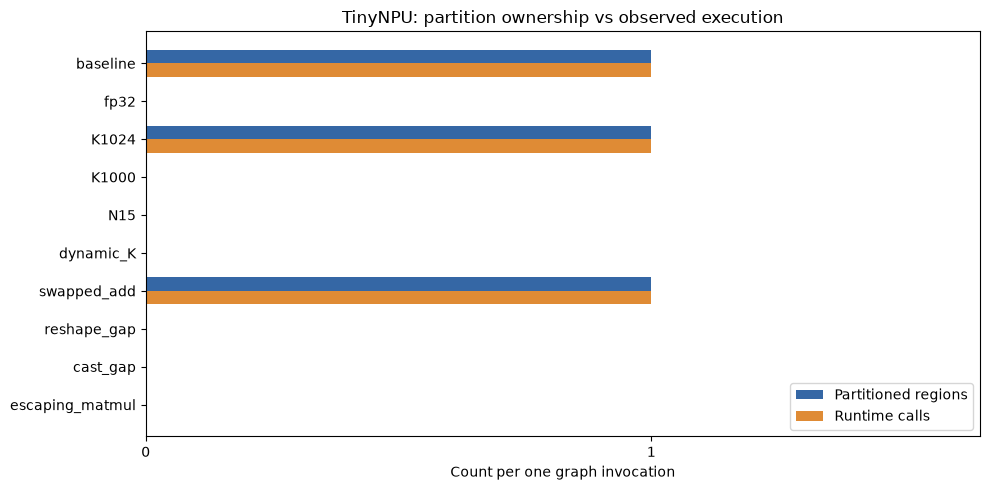

In [10]:
y=np.arange(len(case_table))  # 每一个受控实验在纵轴上的位置
fig,ax=plt.subplots(figsize=(10,5))
ax.barh(y-0.18,case_table.accepted_regions,height=0.35,label='Partitioned regions',color='#3567a5')
ax.barh(y+0.18,case_table.runtime_calls,height=0.35,label='Runtime calls',color='#df8b35')
ax.set(yticks=y,yticklabels=case_table['case'],xticks=[0,1],xlim=(0,1.65),
       xlabel='Count per one graph invocation',title='TinyNPU: partition ownership vs observed execution')
ax.invert_yaxis()
ax.legend(loc='lower right')
fig.tight_layout()
fig.savefig(RUN/'partition_vs_execution.png',dpi=150)
plt.show()

## 11 · 证据包与复现身份

产物保存到独立时间戳目录，不覆盖旧实验。包含各阶段 IR、JSON 指令、TIR 桥、三条正常路径输入/逐层输出/reference、故障表和 SHA256。Python runtime 注册依赖当前进程；**这里没有可独立部署的二进制包**，重开进程需要重新执行注册 cells。

未测 latency，也没有 speedup：Python 回调、NumPy 数组复制与解释执行会混入测量，无法回答 NPU kernel 快慢。下一本若做 benchmark，先锁定计时边界、warm-up、同步和正确性门禁，再谈 P50/P95。

In [11]:
case_table.to_csv(RUN/'partition_cases.csv',index=False)
normal_table.to_csv(RUN/'normal_parity.csv',index=False)
pd.DataFrame(fault_rows).to_csv(RUN/'runtime_faults.csv',index=False)
(RUN/'codegen_specs.json').write_text(json.dumps(codegen_log,indent=2))
(RUN/'bridges.tir.py').write_text('\n\n'.join(bridge_ir))
# 原始事件保留 layer 数值，而不仅是 completed 字符串。
def json_default(value):
    if isinstance(value,np.ndarray): return value.tolist()
    raise TypeError(type(value))
(RUN/'runtime_events.json').write_text(json.dumps(runtime_log,default=json_default,indent=2))
notebook_path=ROOT/'notebooks/project3_backend_autotuning/02_toy_npu_codegen_runtime_fault_lab.ipynb'
# code cells hash 避开执行输出改变 notebook 文件 hash 的循环依赖。
import nbformat
source=nbformat.read(notebook_path,as_version=4)
code_sha=hashlib.sha256('\n'.join(c.source for c in source.cells if c.cell_type=='code').encode()).hexdigest()
manifest={'tvm':tvm.__version__,'python':platform.python_version(),'platform':platform.platform(),
          'target':TARGET,'seed':SEED,'threads':1,'backend':BACKEND,'code_cells_sha256':code_sha,
          'precision':'FP16 boundaries; FP32 NumPy arithmetic',
          'execution':'synchronous CPU interpreter through LLVM packed-call bridge',
          'latency_measured':False,'NPU_executed':False,
          'uv_lock_sha256':hashlib.sha256((ROOT/'uv.lock').read_bytes()).hexdigest(),
          'files':{p.name:hashlib.sha256(p.read_bytes()).hexdigest() for p in RUN.iterdir() if p.is_file()}}
(RUN/'manifest.json').write_text(json.dumps(manifest,indent=2))
display(Markdown(f'本轮：**{len(normal_rows)} 个正常 pattern、{len(case_rows)} 个分区实验、'
                 f'{len(fault_rows)} 个故障门禁均通过**；恒等 Reshape 修复与故障恢复通过。'))
print(RUN)

本轮：**3 个正常 pattern、10 个分区实验、5 个故障门禁均通过**；恒等 Reshape 修复与故障恢复通过。

/Users/yhwang/infer-proj/artifacts/toy_npu/20260919T020521064207Z


## 12 · 读完后，你应该能定位到哪一层？

1. **FP32 为什么根本没进 kernel 讨论？** pattern 找到了，但 support predicate 拒绝，backend region=0；host 执行仍可正确。
2. **dynamic K=32，为什么没交给 backend？** 编译时只有符号 K。当前策略 static-only，运行时传 32 不能倒推编译时已证明对齐。
3. **交换 Add 为什么需要检查 codegen？** pattern 与数学等价不同；匹配后外部函数的参数顺序还可能改变，必须按 IR 生成参数映射。
4. **两个 op 都支持，为什么不能 fusion？** 看中间值是否被 region 外使用、精度/形状/布局/资源合同是否一致；这里 single-output ABI 拒绝 escaping MatMul。
5. **有 Codegen 属性能证明执行吗？** 不能；本本再检查 external_mods、call_dps_packed、runtime event、逐层与最终 parity、故意错误负控。
6. **kernel unavailable 是 fallback 吗？** 这里是 runtime 错误，没有启用自动 fallback。若做 fallback policy，必须显式记录选择、再次验正确性，不能把异常全吞了。
7. **图 fusion 是否省了一次内存写回？** 本实验没有这个证据：NumPy 仍逐 op 创建数组。下一本要真正写融合 kernel，再计 buffer/访问次数。

### M1 与公司平台：哪些经验可以迁移？

| 问题 | 本 M1 Toy 实验 | N93X / AllSpark 内部资料中的对照 |
|---|---|---|
| graph 在哪里？ | Python 创建真实 Relax IR，可 `.script()` dump | 【源码可见 S】`docs/Alchemy-Hauk-Attention-Source-Investigation.md` §2.2–2.3：Python wrapper 通过 native builder 建图 |
| fusion 开关证明什么？ | Composite 只证明 region；runtime trace 与 parity 另验 | 【源码可见 S / 推断 I】同文 §3.1：有 fusion/mem-reuse 开关，不能由开关推定具体融合模式 |
| backend 运行在哪里？ | 已证实 NumPy CPU；未调用 ANE | 真实设备执行必须另采 runtime placement；本 Toy 不能替代板端证据 |

这张表对齐的是验证方法，并不把本教程 JSON、workspace 模型或 FP16 对齐规则当成厂商规格。公司材料只供内部学习，对外面试匿名化。

### 建议亲手改的三个练习

- 把 `K1000` 改成 992：先预测 `992 % 32`，再对比 support reason 和 runtime event。
- 让 workspace budget 刚好等于当前指令输出字节和，再减 1；定位失败是否发生在任何 op 执行之前。
- 在 PyTorch reference 中故意漏掉 bias，确认逐层检查最先停在 Add；不能只靠最终 ReLU 掩盖错误。

后续再分别建立：真正 TIR kernel 与 tail；地址级 layout 实验；Stream/Event/MemoryPool；性能回归调查。它们是后续实验，不假装已经包含在第一本中。

## 可检视源码与参考

- TVM 0.26 API 提醒：tensor 元信息读 `.ty`；结构比较用 `tvm_ffi.structural_equal`；codegen 要返回 runtime Module，所以这里用 `tirx.build`，而非返回 Executable 的 `tvm.compile`。
- 当前虚拟环境 `tvm/relax/backend/pattern_registry.py`：注册 pattern。
- `tvm/relax/backend/utils.py:has_leaking_intermediate_variables`：def-use 边界检查。
- `tvm/relax/transform/transform.py:PatternCheckContext`：`annotated_expr` 的 key 是字符串。
- [TVM 官方 BYOC 架构](https://tvm.apache.org/docs/arch/external_library_dispatch.html)：pass/外部模块/packed-call 链路；在线文档会更新，本本以已执行的 0.26.0 为准。
- [TVM 官方 Relax VM](https://tvm.apache.org/docs/arch/relax_vm.html)：host VM 执行模型。
- `docs/Detailed‑Answers‑for‑Edge‑AI‑Deployment.md` §0、§一·1：正确性与部署证据纪律。

编辑器中对 `FuseOpsByPattern` / `register_patterns` 点 Go to Definition；若想看 C++ pass 实现，参照 Apache TVM 源码 `src/relax/transform/run_codegen.cc`。只看 `Codegen` 字符串无法推定底层实现。